## Interactive notebook to test using aiida-abacus

This notebook is intended to be used with mybinder.org. ([![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/MCresearch/aiida-abacus/HEAD)) 

For local use, one needs to:
- Initialize your AiiDA profile (`verdi preso`)
- Install additional python dependenecies (`pip install sumo aiida-vasp ase-weas-widget pymatgen`)
- Install the graphviz binary package for generating provenance graph (`sudo apt install graphivz`)

In [1]:
%load_ext aiida
%aiida

Loaded AiiDA DB environment - profile name: presto.

In [2]:
from aiida import orm
from aiida.common.links import LinkType
from aiida.engine import run_get_node
from aiida.manage.caching import enable_caching
from aiida.plugins import WorkflowFactory
from aiida.tools.visualization.graph import Graph
from ase.build import bulk

In [3]:
from aiida_vasp.utils.sumo import get_sumo_bands_plotter


def show_bands(worknode):
    plotter = get_sumo_bands_plotter(worknode.outputs.band_structure, structure=worknode.outputs.primitive_structure)
    return plotter

In [4]:
from ase.visualize import view

In [6]:
workflow = WorkflowFactory("abacus.relax")
builder = workflow.get_builder_from_protocol(
    code="abacus@localhost",
    structure=orm.StructureData(ase=bulk("Si", "diamond", 6)),
    options={"resources": {"num_machines": 1, "tot_num_mpiprocs": 1}, "prepend_text": "export OMP_NUM_THREADS = 1"},
    overrides={
        "base": {"kpoints_distance": 0.5, "abacus": {"parameters": {"input": {"ecutwfc": 20}}}},
        "base_final_scf": {"kpoints_distance": 0.5, "abacus": {"parameters": {"input": {"ecutwfc": 20}}}},
    },
)

In [7]:
builder

Process class: AbacusRelaxWorkChain
Inputs:
base:
  abacus:
    code: abacus@localhost
    metadata:
      options:
        max_wallclock_seconds: 43200
        prepend_text: export OMP_NUM_THREADS = 1
        resources:
          num_machines: 1
          tot_num_mpiprocs: 1
        stash: {}
        withmpi: true
    monitors: {}
    parameters:
      input:
        basis_type: pw
        cal_force: true
        cal_stress: true
        calculation: cell-relax
        device: cpu
        ecutwfc: 20
        force_thr: 1e-3
        ks_solver: dav_subspace
        precision: double
        scf_nmax: 100
        scf_thr: 4.0e-10
        smearing_sigma: 0.015
        stress_thr: 0.5
        symmetry: 1
    pseudos:
      Si: ''
  kpoints_distance: 0.5
  kpoints_force_parity: false
  max_iterations: 5
  metadata: {}
base_final_scf:
  abacus:
    code: abacus@localhost
    metadata:
      options:
        max_wallclock_seconds: 43200
        prepend_text: export OMP_NUM_THREADS = 1
       

Submit the calculation

In [8]:
with enable_caching():
    results, node = run_get_node(builder)
    # submit(builder)  # Normally one would use submit so the job is run by the daemon

08/07/2025 02:18:35 AM <3015> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REPORT] [456|AbacusRelaxWorkChain|run_relax]: launching AbacusBaseWorkChain<459>
08/07/2025 02:18:37 AM <3015> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REPORT] [459|AbacusBaseWorkChain|run_process]: launching AbacusCalculation<464> iteration #1
08/07/2025 02:18:39 AM <3015> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REPORT] [459|AbacusBaseWorkChain|results]: work chain completed after 1 iterations
08/07/2025 02:18:39 AM <3015> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REPORT] [459|AbacusBaseWorkChain|on_terminated]: remote folders will not be cleaned
08/07/2025 02:18:39 AM <3015> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REPORT] [456|AbacusRelaxWorkChain|inspect_relax]: after iteration 1 cell volume of relaxed structure is 41.12920157495352
08/07/2025 02:18:40 AM <3015> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REP

In [ ]:
!verdi archive create -N {node.pk} -- {node.uuid[:8]}.aiida

## Visit the properties computed

Raw inputs to the calculations

In [9]:
node.called_descendants[2].inputs.parameters.get_dict()

{'input': {'calculation': 'cell-relax',
  'symmetry': 1,
  'basis_type': 'pw',
  'ecutwfc': 20,
  'scf_thr': 4e-10,
  'force_thr': '1e-3',
  'stress_thr': 0.5,
  'cal_force': True,
  'cal_stress': True,
  'smearing_sigma': 0.015,
  'scf_nmax': 100,
  'device': 'cpu',
  'ks_solver': 'dav_subspace',
  'precision': 'double'}}

In [10]:
print(node.called_descendants[2].base.repository.get_object_content("INPUT"))

INPUT_PARAMETERS
calculation                   cell-relax
symmetry                      1
basis_type                    pw
ecutwfc                       20
scf_thr                       4e-10
force_thr                     1e-3
stress_thr                    0.5
cal_force                     True
cal_stress                    True
smearing_sigma                0.015
scf_nmax                      100
device                        cpu
ks_solver                     dav_subspace
precision                     double
suffix                        aiida
pseudo_dir                    ./pseudo/
orbital_dir                   ./orbital/


In [11]:
node.outputs.misc.get_dict()

{'force_unit': 'eV/Angstrom',
 'stress_unit': 'KBAR',
 'all_forces': [[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]],
  [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]]],
 'all_stress': [[[-0.0846524643, -0.0, 0.0],
   [0.0, -0.0846524643, -0.0],
   [0.0, -0.0, -0.0846524643]],
  [[-0.0846524643, -0.0, 0.0],
   [0.0, -0.0846524643, -0.0],
   [0.0, -0.0, -0.0846524643]],
  [[-0.0846524643, -0.0, 0.0],
   [0.0, -0.0846524643, -0.0],
   [0.0, -0.0, -0.0846524643]]],
 'final_forces': [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]],
 'final_stress': [[-0.0846524643, -0.0, 0.0],
  [0.0, -0.0846524643, -0.0],
  [0.0, -0.0, -0.0846524643]],
 'number_of_bands': 14,
 'fermi_level': 6.3881251438,
 'total_energy': '-230.0690132520136615'}

In [12]:
view(node.outputs.structure.get_ase(), viewer="weas", presets="vesta,legend")

WeasWidget(children=(BaseWidget(atoms={'species': {'Si': 'Si'}, 'cell': [0.0, 2.7369429835, 2.7369429835, 2.73…

NOTE: If you encounter JavaScript error, save the notebook and refresh the browser page. 

## Provenance graph

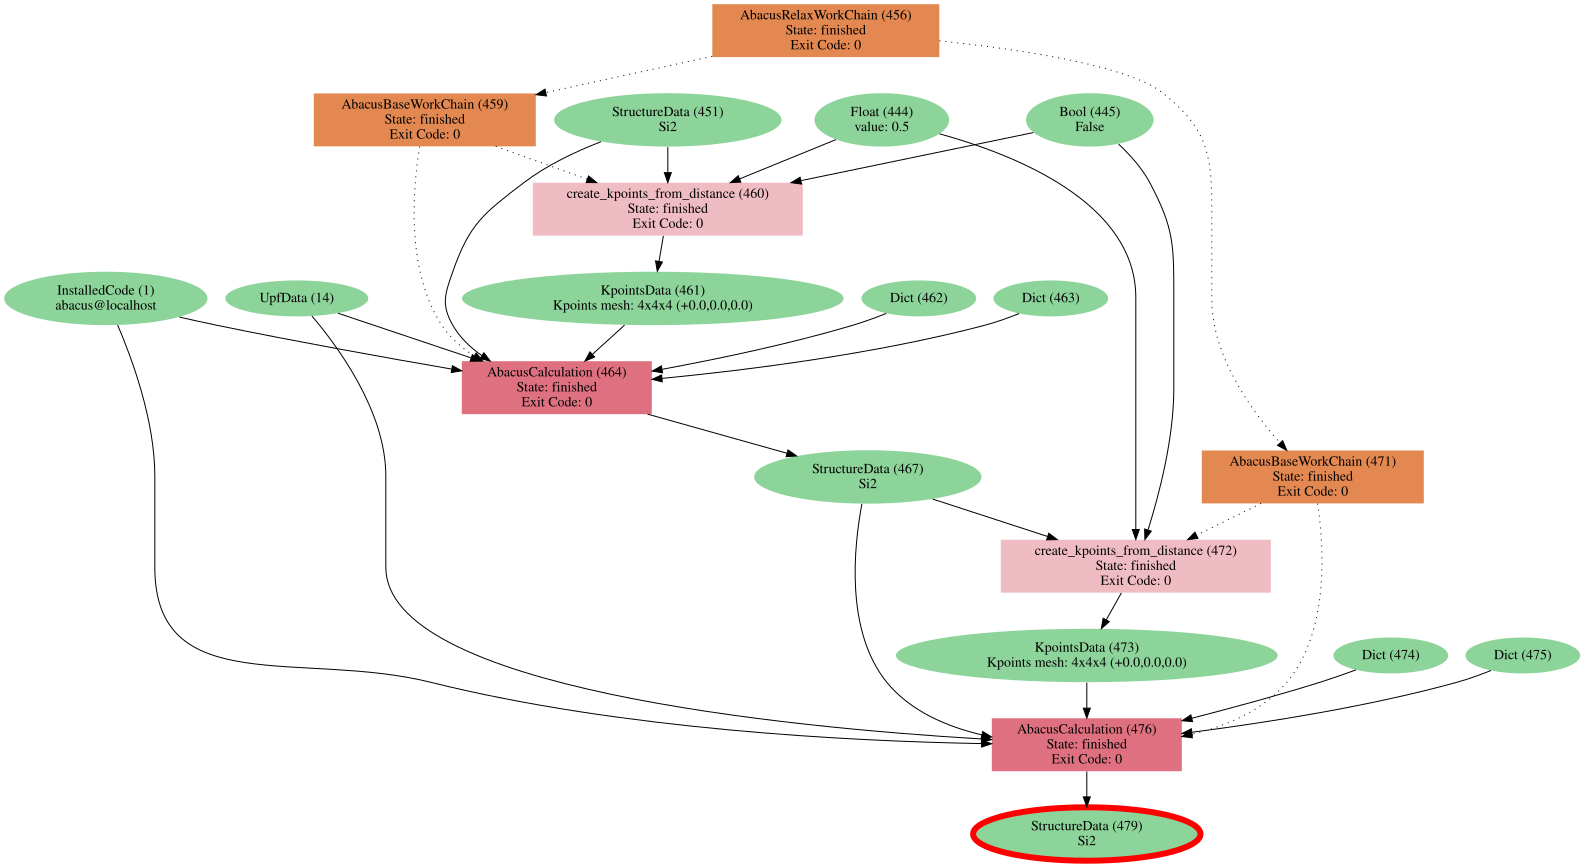

In [13]:
g = Graph()

g.recurse_ancestors(
    node.outputs.structure,
    link_types=[
        LinkType.CREATE,
        LinkType.CALL_WORK,
        # LinkType.INPUT_WORK,
        LinkType.INPUT_CALC,
        LinkType.CALL_CALC,
        # , LinkType.INPUT_WORK
    ],
)

g.graphviz

In [14]:
graph = g.graphviz

graph.render(outfile="silicon_relax.pdf")

'silicon_relax.pdf'

## Importing a band structure calculation

Its provenance and be inspected and visualized as well

In [15]:
!verdi archive import 6d345ce7.aiida

Report: starting import: 6d345ce7.aiida
Report: Parameters
-------------------------------  ----------------
Archive                          6d345ce7.aiida
New Node Extras                  keep
Merge Node Extras (in database)  (k)eep
Merge Node Extras (in archive)   do (n)ot create
Merge Node Extras (in both)      (l)eave existing
Merge Comments                   leave
Computer Authinfos               exclude

Report: Skipping 1 existing User(s)
Report: Skipping 1 existing Computer(s)
Report: Collecting Node(s) ...
Report: Skipping 74 existing Node(s)
Report: Skipping 25 existing Log(s)
Report: Gathering existing 'create' Link(s)
Report: Skipped 22 existing 'create' Link(s)                       
Report: Gathering existing 'return' Link(s)
Report: Skipped 22 existing 'return' Link(s)                       
Report: Gathering existing 'input_calc' Link(s)
Report: Skipped 40 existing 'input_calc' Link(s)                   
Report: Gathering existing 'input_work' Link(s)
Report: Skipped 5

In [16]:
band_node = orm.load_node("6d345ce7")

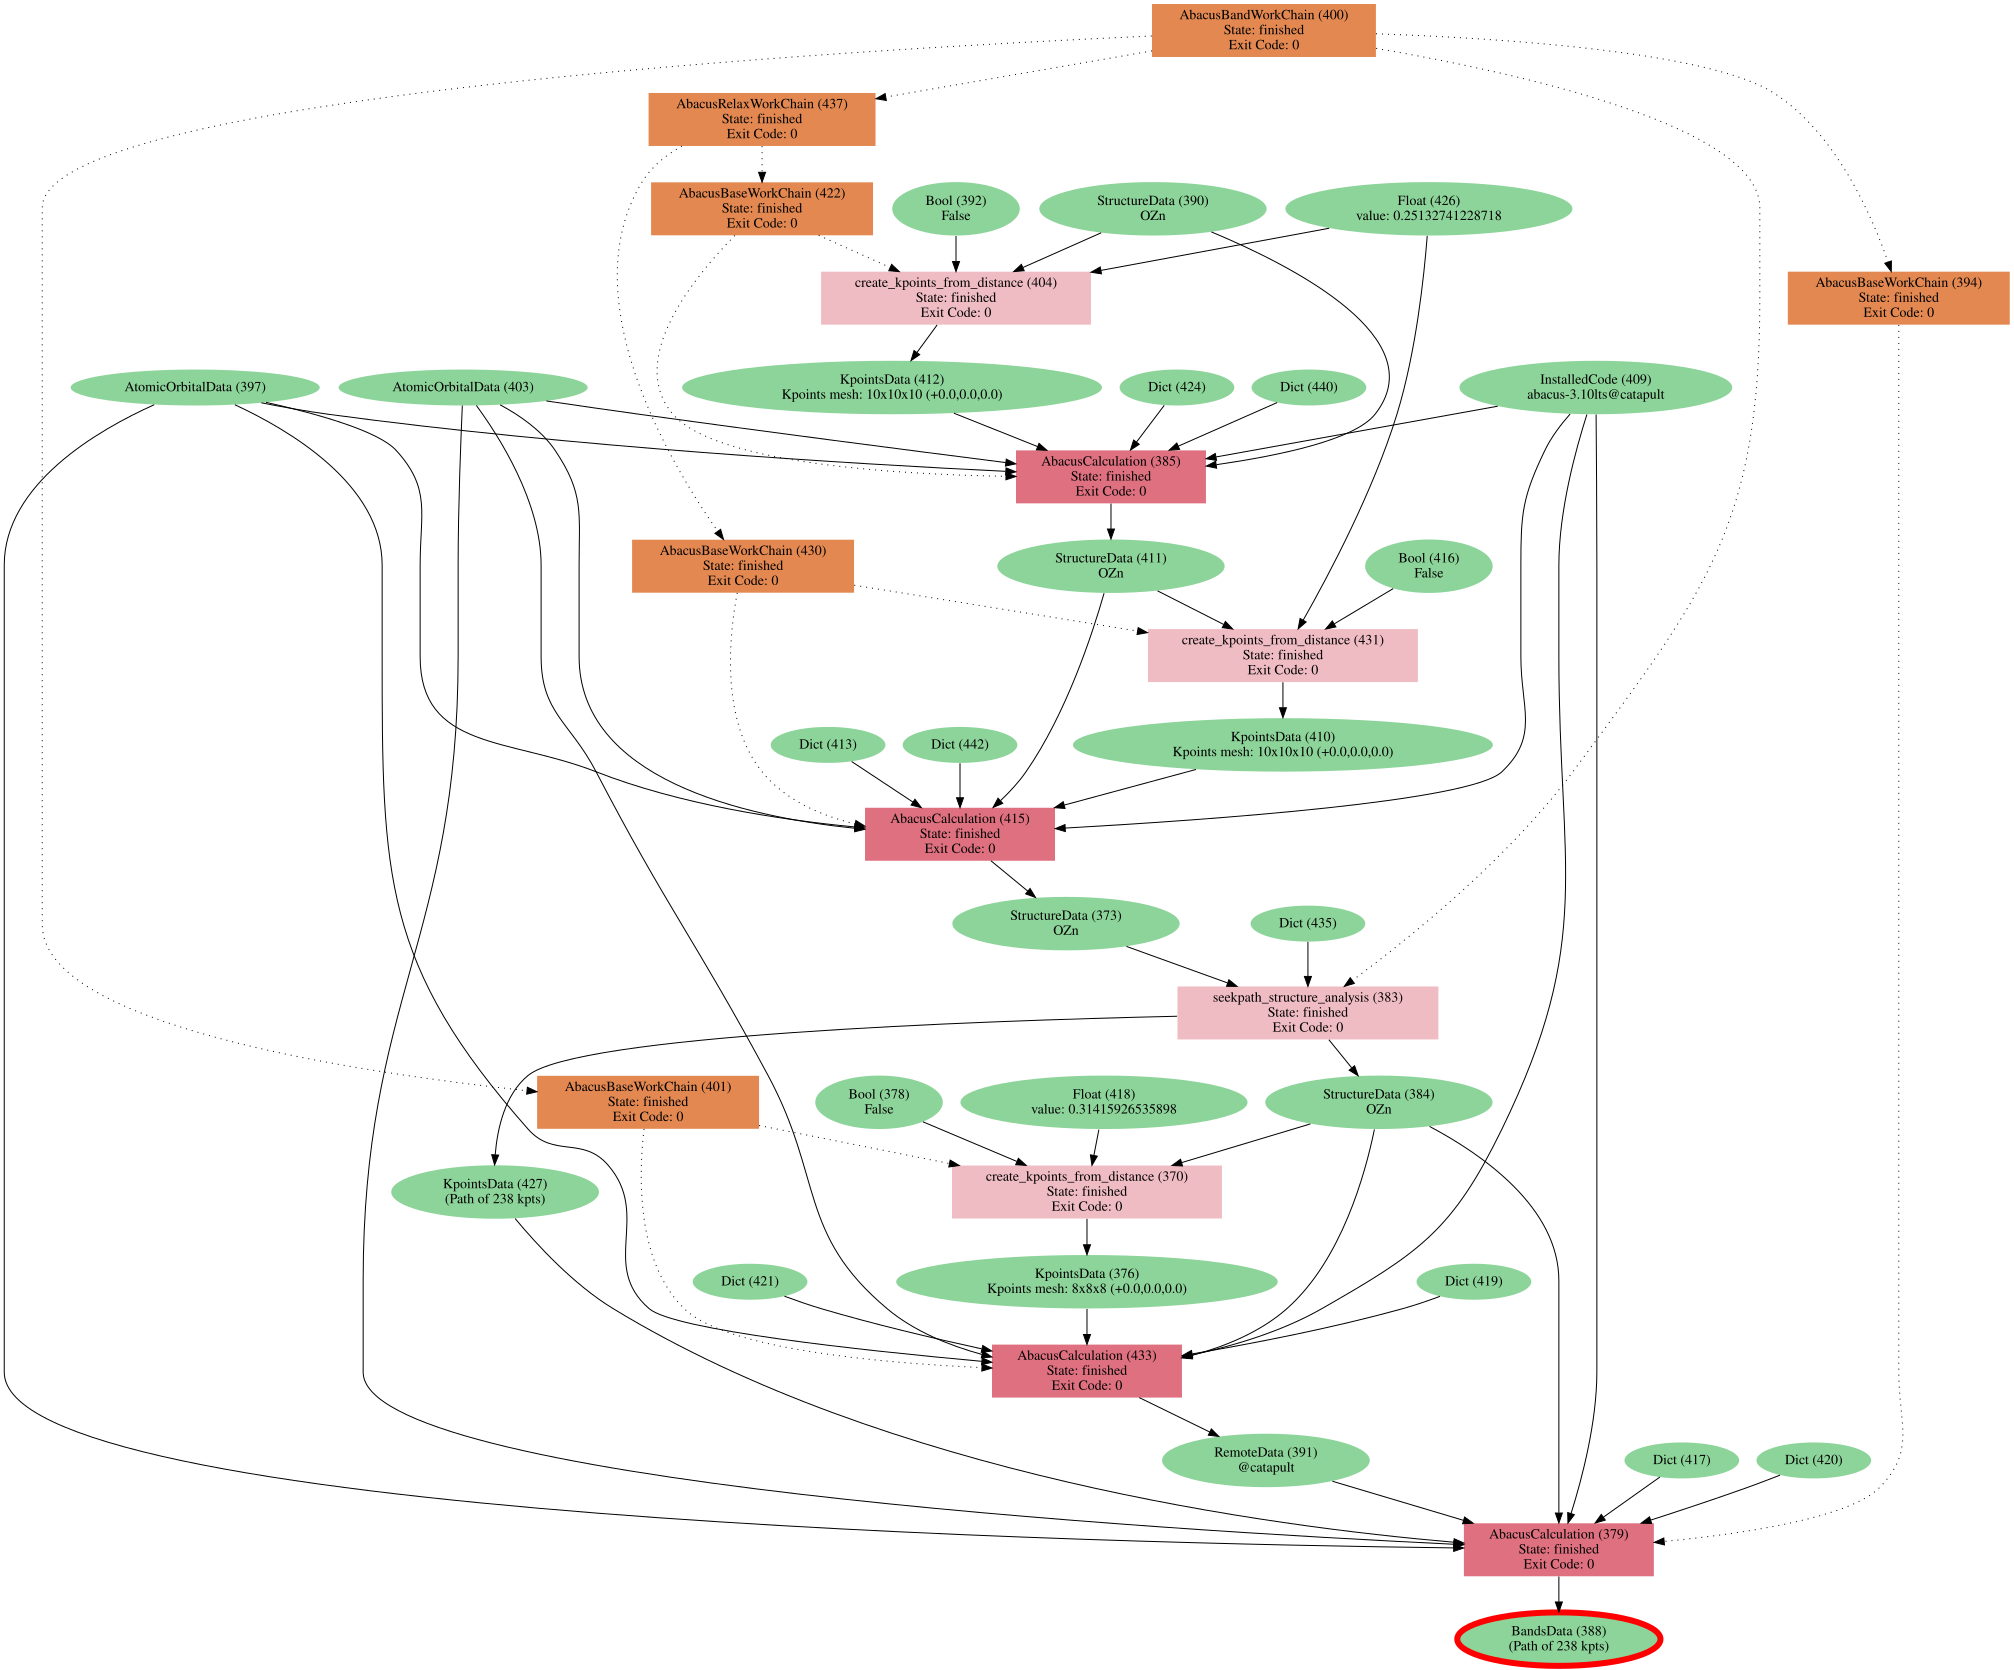

In [17]:
g = Graph()

g.recurse_ancestors(
    band_node.outputs.band_structure,
    link_types=[
        LinkType.CREATE,
        LinkType.CALL_WORK,
        # LinkType.INPUT_WORK,
        LinkType.INPUT_CALC,
        LinkType.CALL_CALC,
        # , LinkType.INPUT_WORK
    ],
)

g.graphviz
graph = g.graphviz
graph.render(outfile="band_provenance.pdf")
g.graphviz

<module 'matplotlib.pyplot' from '/srv/conda/envs/notebook/lib/python3.10/site-packages/matplotlib/pyplot.py'>

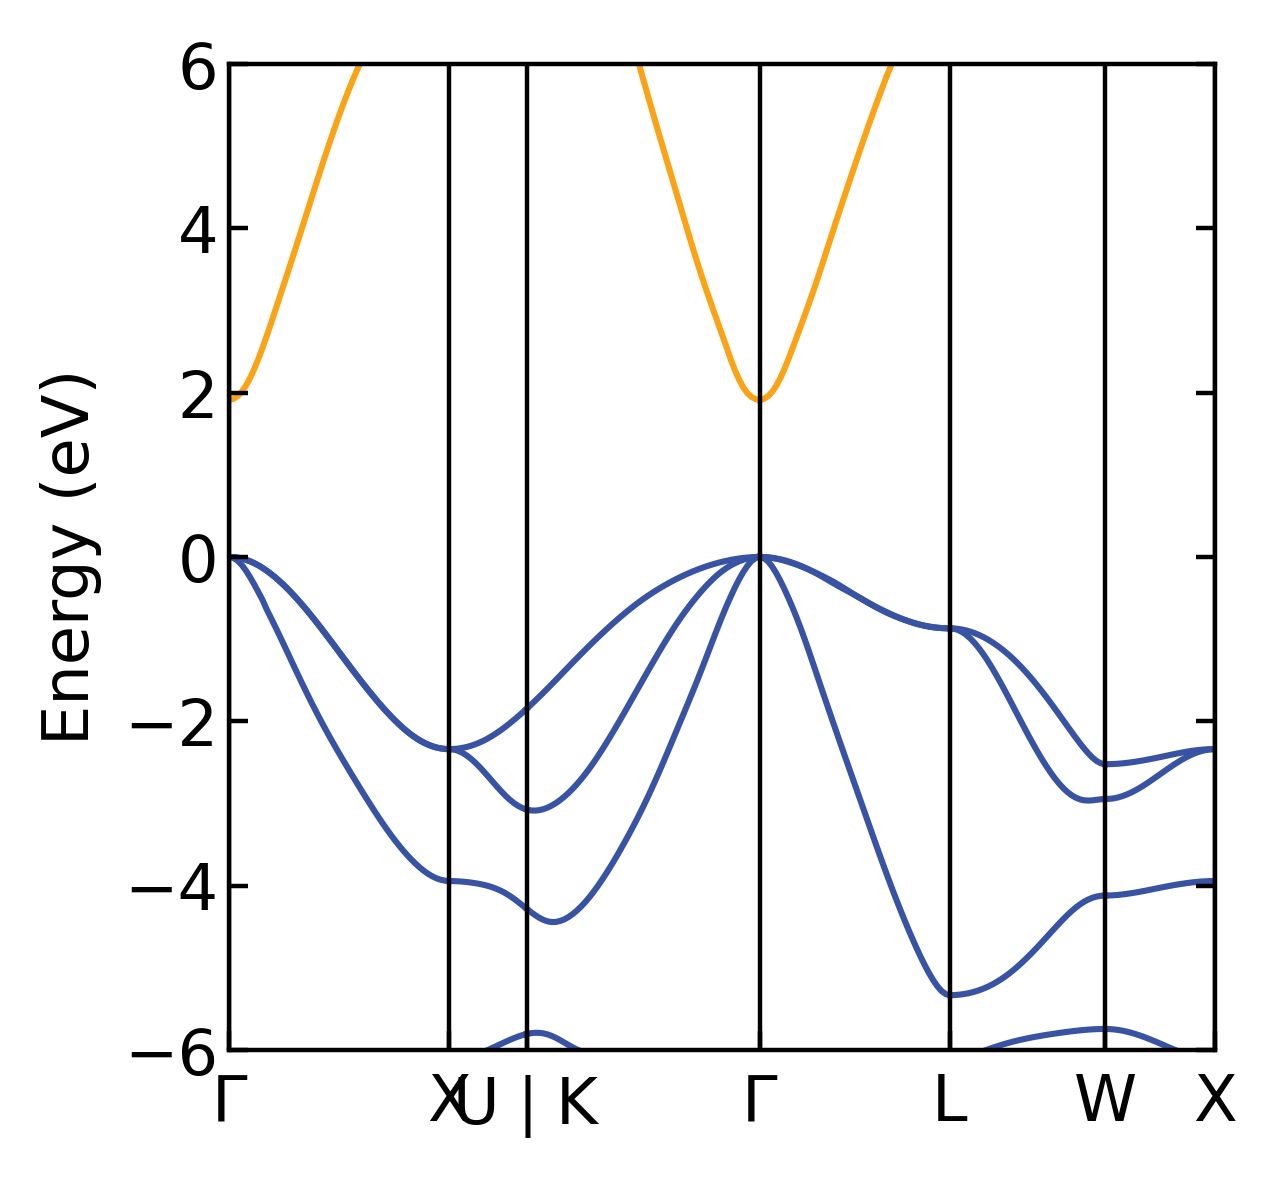

In [18]:
show_bands(band_node).get_plot()

One can also use the visualization method of BandsData, but it is not as pretty as that with sumo

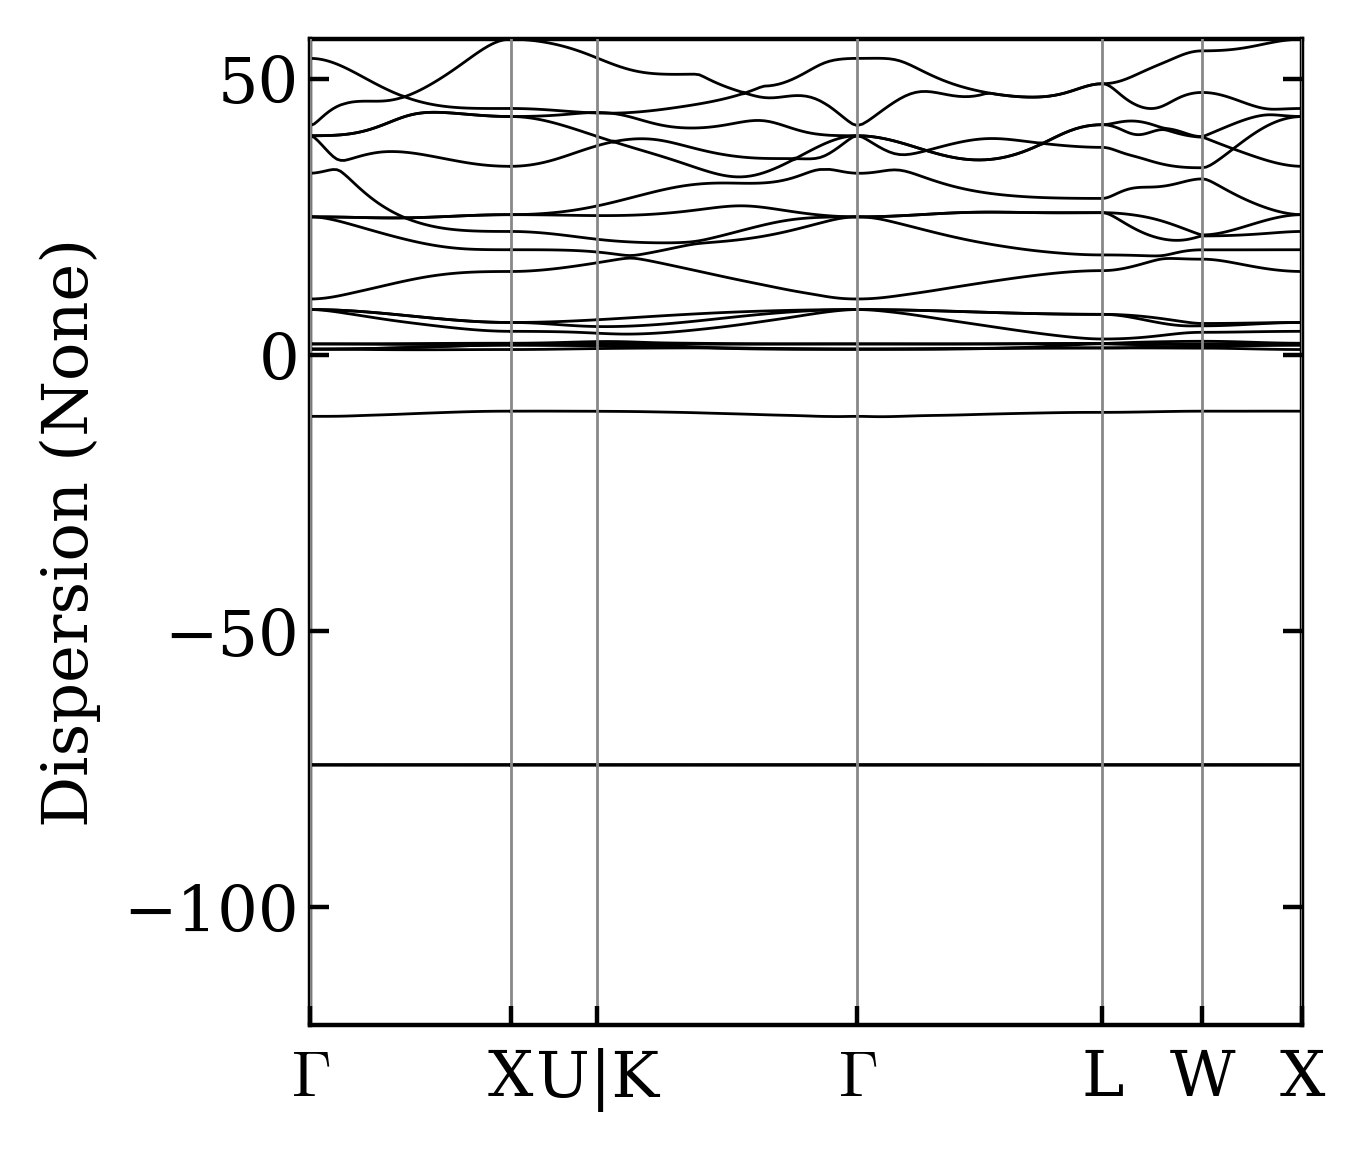

In [19]:
band_node.outputs.band_structure.show_mpl()

In [20]:
view(band_node.outputs.primitive_structure.get_ase(), viewer="weas", presets="vesta,ball,legend")

WeasWidget(children=(BaseWidget(atoms={'species': {'Zn': 'Zn', 'O': 'O'}, 'cell': [0.0, 2.3083468044, 2.308346…